# Phase 4 - Signal Engine

Turns regime fair value into ranked, explainable trade signals.

- **Signal** = z-scored residual: `z = (actual - fair_value) / resid_std_train[regime]`.
  - `z > 0` -> spread **rich** vs regime fair value -> **SHORT** the spread.
  - `z < 0` -> spread **cheap** -> **LONG** the spread.
- **State machine:** entry `|z|>=2`, exit `|z|<=0.5`, stop `|z|>=3`.
- **Rank** active opportunities by `|z|`.

**Safeguards (added after the spring-2026 dislocation finding):**
1. **Out-of-distribution flag** - if the actual spread is outside the training range or `|z|` is extreme (`>=Z_EXTREME`), the move is beyond what the model learned. We do **not** issue a clean entry; it goes to a separate *dislocation watch* with low confidence.
2. **Persistence / episodes** - consecutive same-direction breaches collapse into one episode (entry date, duration, peak z), so a sustained dislocation is one event, not 69 signals.
3. **Confidence tiers** from regime support, near-boundary flag, and OOD.

In [1]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 40)

CACHE = Path("cache"); INSTRUMENT="CL"; STRUCTURE="c1-c2"
ENTRY, EXIT, STOP = 2.0, 0.5, 3.0
Z_EXTREME = 4.0

s = pd.read_parquet(CACHE / f"{INSTRUMENT}_fairvalue.parquet").sort_index()
std = s["resid_std_train"].replace(0, np.nan)
s["z"] = s["residual"] / std
s["direction"] = np.where(s["z"] > 0, "SHORT", "LONG")

# training range of the actual spread -> out-of-distribution test
tr = s[s.split=="train"]["cal_1_2"]
lo, hi = tr.min(), tr.max()
s["ood"] = (s["cal_1_2"] < lo) | (s["cal_1_2"] > hi) | (s["z"].abs() >= Z_EXTREME)
print(f"train spread range: [{lo:.2f}, {hi:.2f}]")
print("z describe (test):\n", s[s.split=='test']['z'].describe().round(2))
print("OOD days  train:", int(s[s.split=='train'].ood.sum()),
      "| test:", int(s[s.split=='test'].ood.sum()), "of", int((s.split=='test').sum()))

train spread range: [-3.12, 4.20]
z describe (test):
 count    69.00
mean      8.69
std       8.35
min      -0.56
25%       2.72
50%       7.29
75%      11.33
max      35.16
Name: z, dtype: float64
OOD days  train: 22 | test: 45 of 69


## 1. Validate the premise: does a |z|>=2 spread actually mean-revert?
If the signal has value, residuals should shrink in the days after a breach. Checked on **train** only.

In [2]:
z = s["z"]; absz = z.abs()
breach = absz >= ENTRY
print(f"breach days (|z|>=2) in train: {int(breach[s.split=='train'].sum())}")
rows=[]
for h in [5,10,20]:
    fut = absz.shift(-h)
    m = breach & (s.split=="train") & fut.notna()
    rows.append((h, round(absz[m].mean(),2), round(fut[m].mean(),2),
                 f"{(1-fut[m].mean()/absz[m].mean())*100:+.0f}%"))
print(pd.DataFrame(rows, columns=["horizon_days","|z|_now","|z|_+h","reversion"]).to_string(index=False))
print("\n(negative reversion %% = |z| shrank toward fair value -> premise holds)")

breach days (|z|>=2) in train: 193
 horizon_days  |z|_now  |z|_+h reversion
            5     3.23    2.30      +29%
           10     3.23    2.15      +33%
           20     3.23    2.07      +36%

(negative reversion %% = |z| shrank toward fair value -> premise holds)


## 2. Signal state machine (entry / hold / exit / stop, OOD-aware)

In [3]:
def run_states(df):
    state=[]; pos=0; pos_dir=0
    for zz, ood in zip(df["z"].values, df["ood"].values):
        a=abs(zz); d=1 if zz>0 else -1
        if pos==0:
            if a>=ENTRY and not ood: pos=1; pos_dir=d; st="ENTRY"
            elif a>=ENTRY and ood:   st="DISLOCATION"   # flagged, not traded
            else: st="flat"
        else:
            if d!=pos_dir or a<=EXIT: pos=0; st="EXIT"
            elif a>=STOP: pos=0; st="STOP"
            else: st="HOLD"
        state.append(st)
    return state
s["state"]=run_states(s)
print(s[s.split=='test']["state"].value_counts())
s[s.split=='test'][["cal_1_2","fair_value","z","direction","state","ood","regime_eff"]].tail(8).round(2)

state
DISLOCATION    43
flat            8
ENTRY           6
HOLD            6
STOP            4
EXIT            2
Name: count, dtype: int64


,cal_1_2,fair_value,z,direction,state,ood,regime_eff
date,,,,,,,
2026-05-14,4.30,0.87,8.75,SHORT,DISLOCATION,True,H|*|Back
2026-05-15,4.37,0.90,8.87,SHORT,DISLOCATION,True,H|*|Back
2026-05-16,3.92,0.89,7.73,SHORT,DISLOCATION,True,H|*|Back
2026-05-18,4.25,0.89,8.58,SHORT,DISLOCATION,True,H|*|Back
2026-05-19,4.28,0.90,8.63,SHORT,DISLOCATION,True,H|*|Back
2026-05-20,4.20,1.08,4.70,SHORT,DISLOCATION,True,M|H|Back
2026-05-21,3.25,1.06,3.30,SHORT,ENTRY,False,M|H|Back
2026-05-22,3.35,1.09,3.40,SHORT,STOP,False,M|H|Back


## 3. Episodes: collapse consecutive breaches into one event

In [4]:
active = s["state"].isin(["ENTRY","HOLD","DISLOCATION"])
ep_id = (active & ~active.shift(1, fill_value=False)).cumsum().where(active)
s["episode"]=ep_id
eps=[]
for eid, g in s[active].groupby("episode"):
    eps.append(dict(episode=int(eid), start=g.index[0].date(), end=g.index[-1].date(),
        days=len(g), dir=g["direction"].iloc[0], peak_z=round(g["z"].abs().max(),2),
        regime=g["regime_eff"].mode().iloc[0], ood=bool(g["ood"].any()),
        split=g["split"].iloc[-1]))
episodes=pd.DataFrame(eps)
print(f"total episodes: {len(episodes)} (vs {int(active.sum())} active days)")
episodes.tail(10)

total episodes: 58 (vs 431 active days)


,episode,start,end,days,dir,peak_z,regime,ood,split
48,49,2025-01-13,2025-01-16,4,SHORT,2.20,L|L|Back,False,train
49,50,2025-05-31,2025-06-19,17,SHORT,2.53,L|H|Back,False,train
50,51,2025-12-27,2025-12-27,1,LONG,2.77,H|L|Flat,False,train
51,52,2026-01-17,2026-01-17,1,LONG,2.27,M|*|Flat,False,train
52,53,2026-03-05,2026-03-05,1,SHORT,2.41,M|H|Back,False,test
53,54,2026-03-07,2026-03-11,4,SHORT,4.22,M|H|Back,True,test
54,55,2026-03-14,2026-03-14,1,SHORT,2.97,M|H|Back,False,test
55,56,2026-03-23,2026-03-25,3,SHORT,2.94,M|H|Back,False,test
56,57,2026-03-27,2026-04-20,20,SHORT,35.16,H|*|Back,True,test
57,58,2026-04-22,2026-05-21,26,SHORT,15.16,H|*|Back,True,test


## 4. Confidence tier + ranked opportunities

In [5]:
# regime support (train rows per regime) for reliability
sup = s[s.split=="train"].groupby("regime_eff").size().rename("regime_n")
s = s.join(sup, on="regime_eff")
def tier(r):
    if r["ood"]: return "LOW (dislocation)"
    if r["near_boundary"] or r["regime_n"] < 60: return "MEDIUM"
    return "HIGH"
s["confidence"]=s.apply(tier, axis=1)

# ranked tradable opportunities = currently active, non-OOD, by |z|
latest = s.index.max()
book = s[s["state"].isin(["ENTRY","HOLD"])].copy()
book["instrument"]=INSTRUMENT; book["structure"]=STRUCTURE; book["abs_z"]=book["z"].abs()
ranked = book.sort_values("abs_z", ascending=False)[
    ["instrument","structure","regime_eff","cal_1_2","fair_value","z","direction",
     "state","confidence","split"]].round(2)
print("most recent date:", latest.date())
print("\nTradable opportunities (active, non-dislocation), ranked by |z|:")
ranked.head(15)

most recent date: 2026-05-22

Tradable opportunities (active, non-dislocation), ranked by |z|:


,instrument,structure,regime_eff,cal_1_2,fair_value,z,direction,state,confidence,split
date,,,,,,,,,,
2023-02-17,CL,c1-c2,H|M|Flat,-0.25,0.19,-3.88,LONG,ENTRY,HIGH,train
2023-02-22,CL,c1-c2,H|M|Flat,-0.23,0.19,-3.70,LONG,ENTRY,HIGH,train
2022-12-07,CL,c1-c2,L|*|Flat,-0.30,0.39,-3.66,LONG,ENTRY,HIGH,train
2023-02-11,CL,c1-c2,H|M|Flat,-0.20,0.21,-3.62,LONG,ENTRY,MEDIUM,train
2023-02-20,CL,c1-c2,H|M|Flat,-0.22,0.17,-3.54,LONG,ENTRY,MEDIUM,train
2023-06-16,CL,c1-c2,H|M|Flat,-0.19,0.21,-3.49,LONG,ENTRY,HIGH,train
2023-03-01,CL,c1-c2,H|M|Flat,-0.15,0.24,-3.46,LONG,ENTRY,MEDIUM,train
2022-12-05,CL,c1-c2,L|*|Flat,-0.15,0.51,-3.45,LONG,ENTRY,MEDIUM,train
2024-02-20,CL,c1-c2,M|L|Back,1.72,0.59,3.41,SHORT,ENTRY,HIGH,train


## 5. Save signals (dashboard view 4) + plot

saved: cache\CL_signals.parquet


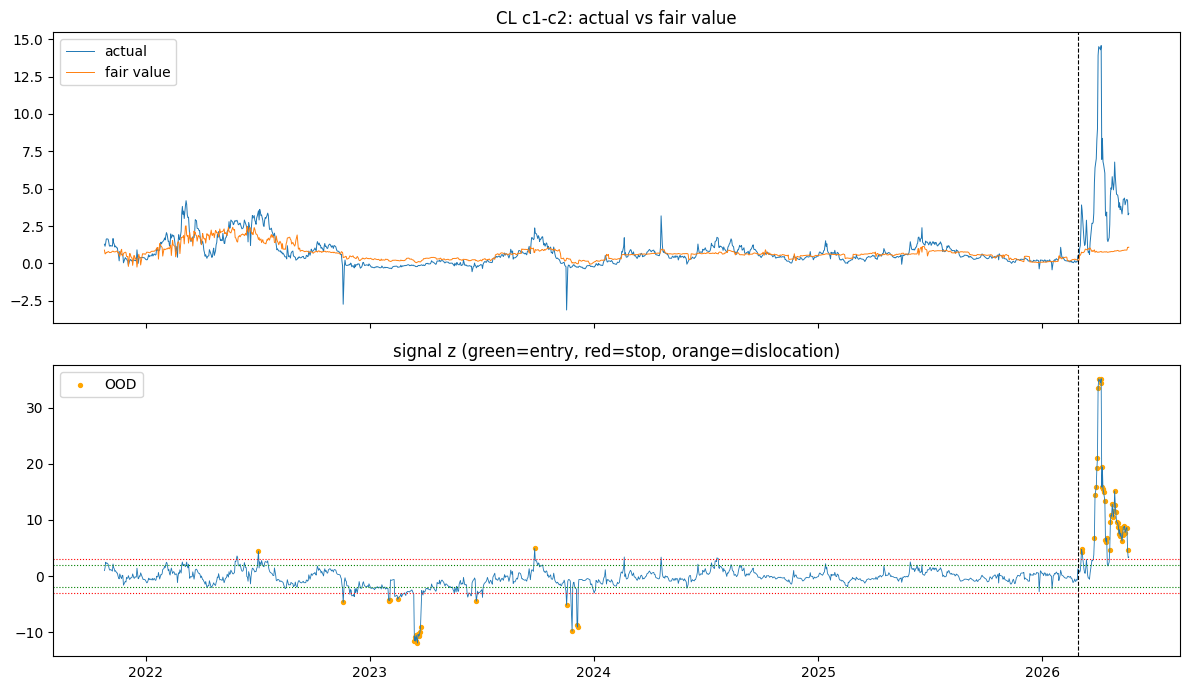

In [6]:
out = CACHE / f"{INSTRUMENT}_signals.parquet"
keep=["cal_1_2","fair_value","residual","z","direction","state","ood","episode",
      "confidence","regime_eff","near_boundary","regime_n","split"]
s[keep].to_parquet(out)
episodes.to_parquet(CACHE / f"{INSTRUMENT}_episodes.parquet")
print("saved:", out)

fig, ax = plt.subplots(2,1, figsize=(12,7), sharex=True)
ax[0].plot(s.index, s["cal_1_2"], lw=.7, label="actual")
ax[0].plot(s.index, s["fair_value"], lw=.7, label="fair value")
ax[0].legend(); ax[0].set_title(f"{INSTRUMENT} {STRUCTURE}: actual vs fair value")
ax[1].plot(s.index, s["z"], lw=.6)
for lvl in (ENTRY,-ENTRY): ax[1].axhline(lvl, color="g", ls=":", lw=.8)
for lvl in (STOP,-STOP):  ax[1].axhline(lvl, color="r", ls=":", lw=.8)
ax[1].scatter(s.index[s.ood], s["z"][s.ood], c="orange", s=8, label="OOD")
ax[1].legend(); ax[1].set_title("signal z (green=entry, red=stop, orange=dislocation)")
for a in ax: a.axvline(pd.Timestamp("2026-03-01"), color="k", ls="--", lw=.8)
plt.tight_layout(); plt.show()